# Eigenfaces face detection

Read Eigenfaces_mathematical_explanation.mkd for a full explanation.

### Data

We will be using the Olivetti dataset from [AT&T Laboratories Cambridge](https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html).

This comprises of 10 images per face, and 40 faces/ classes, so 400 images. The [Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html) version of the dataset has all images at size 64x64, with each pixel represented as a float between [0,1].

if you use a different dataset, remember that Eigenfaces must be grayscale, Olivetti is already, so we will skip this preprocessing step.

### Recap

Remember:
- Eigenfaces is simply applying Principal Component Analysis (PCA) to face image data, and can be used for face recognition tasks.
- Eigenvector: Is a "Direction" in 4096-dimensional space (64 x 64 | h x w). It defines the shape of the feature (e.g., "The Glasses Pattern").
- Eigenvalue: Is the length of that direction in your dataset. It tells you how much your 400 faces actually "stretch" along that Glasses pattern.
- Your Face Embedding: Is just a single number telling you where on that axis a specific face sits (e.g., "This person has 0.8 amount of Glasses").
- Eigenfaces is a relatively simple way to apply dimensionality reduction to create an embedding for face retrieval (recognition). Modern, and more successful, approaches rely on heavy Deep Learning architectures to extract deeper face features - but the overall approach is the same in terms of search and retrieval.

Creating a face database:
- a) Mean Centering: Calculate the "Average Face" of your 400 images and subtract it from every face. This leaves you with only the unique variations from the norm, rather than the raw pixel values.
- b) Solve PCA: Calculate the Eigenvectors and Eigenvalues to find the most important patterns. You keep the top $k$ components (the ones with the biggest Eigenvalues) that explain about 95% of the data. These $k$ vectors are your Eigenfaces.
- c) Projection: Multiply your $k$ Eigenfaces (your transformation matrix) by your original face data. The Math: (k x 4096 pixels) * (4096 pixels x 400 faces) = (k x 400).
- d) The Face Space: The resulting k x 400 matrix is your new library. Every face has been compressed from 4,096 messy pixels into a sleek "fingerprint" of k coordinates.

Inference for Face Recognition:
- e) New Face Projection: Take an unknown face, subtract the original "Average Face," and multiply it by your $k$ Eigenfaces. This turns the new image into its own k-dimensional fingerprint.
- f) Similarity Search: Calculate the Euclidean distance between this new fingerprint and all 400 fingerprints in your library.
- g) Classification: The library entry with the smallest distance is your match. If the distance is too large for all entries, the system labels the face as "Unknown."

### Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

### Common functions

In [ ]:
def plot_images(title, images, n_row=3, n_col=3, random_images=True, col_bar=False):
    """
    Plot a set of images from a collection.
    """
    fig, axs = plt.subplots(n_row, n_col, figsize=(2 * n_col, 2.3 * n_row), layout="constrained")
    fig.suptitle(title, fontsize=16)

    if random_images:
        image_idx = np.random.choice(len(images), size=n_row*n_col, replace=False)
        images = images[image_idx]

    # Pair ax with with images
    for ax, img in zip(axs.flat, images):
        im = ax.imshow(img, cmap="gray")
        ax.axis("off")

    if col_bar: # Single colorbar for the whole figure
        fig.colorbar(im, ax=axs, orientation="horizontal", shrink=0.8)
    plt.show()

### Import Data

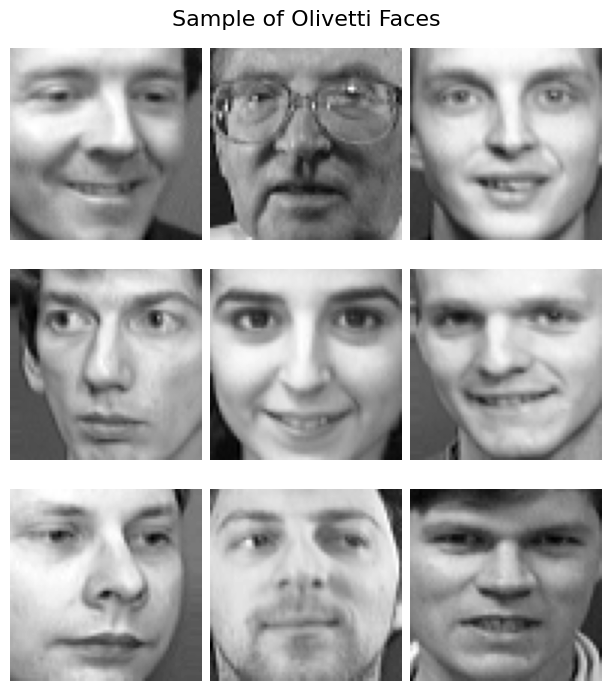

In [ ]:
olivetti_faces = fetch_olivetti_faces()

images_flat = olivetti_faces.data # flattened images 64x64 = 4096
images = olivetti_faces.images
labels = olivetti_faces.target

plot_images("Sample of Olivetti Faces", images)

## Eigenfaces - creating our databse
This is the "memory" that the algorithm will have - our database of faces which we will compare new faces to.

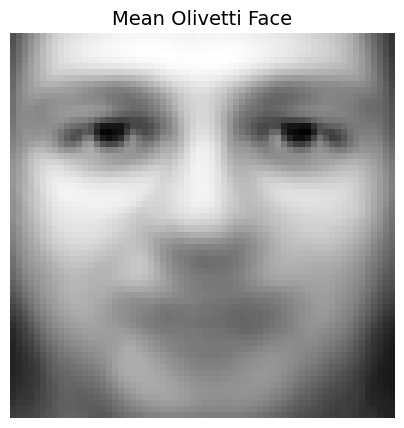

Mean Centered Faces Shape: (400, 4096) | n_faces: 400


In [ ]:
# Center the data (mean face)
# The mean face represents average facial structure.
mean_face = np.mean(images_flat, axis=0)

# Show mean face
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mean_face.reshape(64, 64), cmap="gray")
ax.set_title("Mean Olivetti Face", fontsize=14)
ax.axis("off")
plt.show()

# Subtract mean from every face
# Each mean centered face represents deviation from the avserage.
mean_centered_faces = images_flat - mean_face
print(f"Mean Centered Faces Shape: {mean_centered_faces.shape} | n_faces: {mean_centered_faces.shape[0]}")

To capture 95% of the face data, you need 122 components.


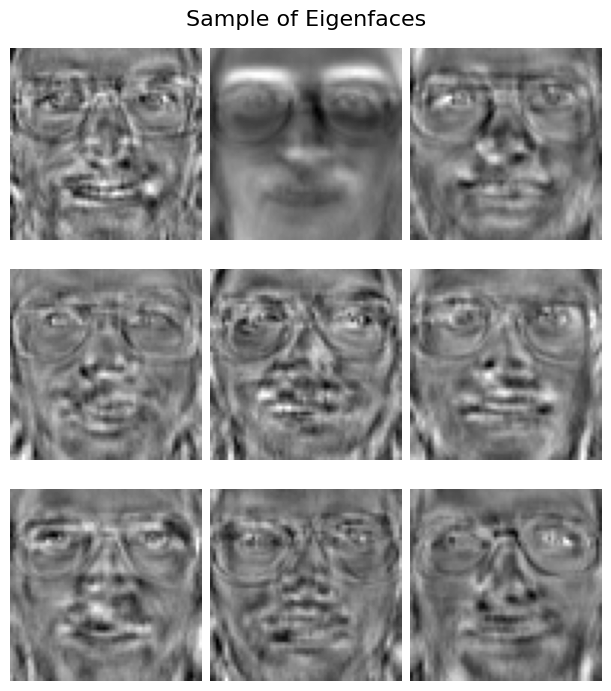

In [ ]:
# Apply PCA
# This is broken down further in the explanation, Eigenfaces_mathematical_explanation.mkd, but since sklearn has a nice PCA class - we will use that.

# First, find number of components which explains 95% varience.
# This will be the number of Eigenfaces (AKA Eigenvectors) you want to keep. Eigenfaces are components which explain varience and Eigenvalues tell you how much varience. 
# Fit PCA without a limit first to see the full spectrum and calculate cumulative variance
pca = PCA(svd_solver='full').fit(mean_centered_faces)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

target_var = 0.95
k_components = np.argmax(cumulative_variance >= target_var)
print(f"To capture 95% of the face data, you need {k_components} components.")

# Re-fit again with that number of components
# Whiten=True
#   Think of whitening as a level playing field for your face data. 
#   It works by taking the top k components you've kept and stretching out the "quiet" identity features—like a sharp chin—while squashing the "loud" environmental stuff, like overhead lighting.
#   This happens right after you project your faces into "Face Space," forcing every Eigenface to have the exact same variance of 1.0.
#   Without this, a bright flash or a shadow looks like a "bigger" change to the computer than a different nose shape.
#   By normalizing the scale, you give a unique facial structure the same "voting power" as a generic shadow.
#   This makes your recognition system much smarter and way more robust against changing lights and camera flashes.
pca = PCA(n_components=k_components, whiten=True, svd_solver='full').fit(mean_centered_faces)

# These are the 'Ghost Images' (Eigenfaces)
# an Eigenface is simply a Principal Component (eigenvector) that has been reshaped back into an image.
# It represents a specific "direction" of variance in your dataset, capturing a common facial feature like a jawline or nose shape.
# Because every face in your image set can be rebuilt by adding these "basis images" together, they act as the fundamental building blocks of your "Face Space."
eigenfaces = pca.components_.reshape((k_components, 64, 64))
plot_images("Sample of Eigenfaces", eigenfaces)

# Transform the faces into "Face Space" (The Embeddings)
# This performs the (k x 4096) * (4096 x 400) = (k x 400) matrix multiplication making each a small vector of length 'k_components'.
face_embeddings = pca.transform(mean_centered_faces)

## Eigenfaces - creating our query and face ret
This is the candidate face that we want to search in our database for to see if we have a match.

------------------------------
Query ID: 0 | Database ID: 0
✅ Match! PCA-based face recognition successful
------------------------------


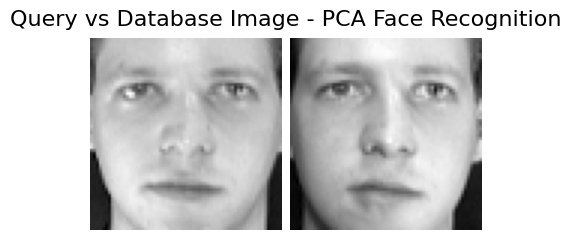

In [ ]:
# Get new face - use exisiting faces for a temp data work around.
# Note: we will have a really high score and return the same face here as we are using a face which we have in our "face database". We will therefore set that distance to 999 as a temp work around to make sure we do not return that face when we search using our distance measure.
# Change this index and play with the results.
query_index = 0
query_new_face = images_flat[query_index]

# Perform Face Recognition (inference)
# We have a new_face that we want to identify.
# First, as with our "training set", center it and project it onto the new coordinates.
new_face_centered = query_new_face - mean_face 
new_face_embedding = pca.transform(new_face_centered.reshape(1, -1))

# Search + retrieval: Find the closest match in your database using a measure of geometric distance: Euclidean, Cosine, Manhattan, etc.
# Fun Fact: this is similar to modern RAG pipelines in agentic search and retrieval
distances = euclidean_distances(new_face_embedding, face_embeddings).flatten()
distances[query_index] = 999 # See note above - work around to ensure the same image is not returned.
database_index = int(np.argmin(distances))

# Compare matching classes/ people
query_label = int(labels[query_index])
database_label = int(labels[database_index])
is_match = (query_label == database_label)
result_msg = "✅ Match! PCA-based face recognition successful" if is_match else "❌ No Match! Faces are complex; PCA has its limits."
print("-" * 30)
print(f"Query ID: {query_label} | Database ID: {database_label}")
print(result_msg)
print("-" * 30)

# See query image and datbase image side by side.
# Individual images are compared and distances between their dimensionality reduced vectors computed, but the class/ ID attached to both is the most important aspect.
# Query image on left and closest database image on right.
plot_images("Query vs Database Image - PCA Face Recognition", np.stack([images[query_index], images[database_index]]), n_row=1, n_col=2, random_images=False)

# Challenge - Inspect the distance array - you'll notice that there tends to be a smaller distance with that of the same class, at least for the Olivetti dataset.
# print(list(zip([int(l) for l in labels], [float(d) for d in distances])))

# Challenge - create a threshold value and supporting code where if no distances within threshold then no face/ person ID is returned.

## Testing Reconstruction
We are keeping around 95% of varience, which means we are losing infomation about our faces. If we try to reconstruct our faces from the reduced size, they won't quite look the same due to the loss of infomation.

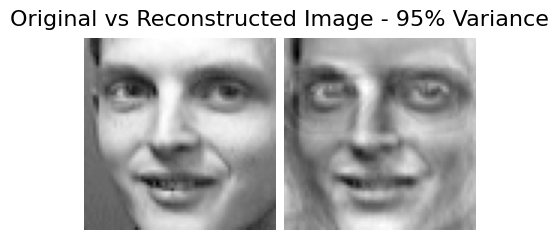

In [ ]:
# Reconstruct - we are keeping around 95% of varience 
# If you want to see what the computer "sees" after 95% compression
reconstructed_index = -1
deconstructed_face = images_flat[reconstructed_index]
deconstructed_face_centered = deconstructed_face - mean_face 
deconstructed_face_centered_face_embedding = pca.transform(deconstructed_face_centered.reshape(1, -1))
reconstructed_face = pca.inverse_transform(deconstructed_face_centered_face_embedding)

original_image = images[reconstructed_index]
reconstructed_face_image = reconstructed_face.reshape(64, 64)
plot_images(f"Original vs Reconstructed Image - {int(target_var*100)}% Variance", np.stack([original_image, reconstructed_face_image]), n_row=1, n_col=2, random_images=False)

# Challenge - play with the target varience in the previous cells to see how it impacts compression (and therefore reconstruction) of our data.

And thats it!

You have successfully:
- Compressed your 400 images into a tiny, searchable matrix.
- Built a Search Engine where identity is just a "distance" between two points in a 150-dimensional room.